Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey.

The Sloan Digital Sky Survey or SDSS is a major multi-spectral imaging and spectroscopic redshift survey using a dedicated 2.5-m wide-angle optical telescope at Apache Point Observatory in New Mexico, United States. Operations started in 1998.

In phase 1, SDSS has released photometry data 357 million (!!!) unique sources and 1.6 million spectra. In phase 2, SDSS observed the same patch of the sky many times ("time domain astronomy", and now we're going to have LSST!)

- Upsample this distribution in hopefully two ways (but at least one of them), using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)
- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation? 

(Hint: It shouldn't. But why?) 

The package [astropy](https://www.astropy.org/) contains a ton of useful astro things. For instance, the best-fit cosmological model from the latest Planck data is:

105783


(array([3.800e+01, 1.930e+02, 4.580e+02, 8.150e+02, 1.011e+03, 1.510e+03,
        1.591e+03, 1.726e+03, 1.627e+03, 1.821e+03, 1.854e+03, 1.927e+03,
        1.724e+03, 1.898e+03, 1.969e+03, 1.955e+03, 1.973e+03, 2.023e+03,
        2.193e+03, 2.395e+03, 2.477e+03, 2.365e+03, 2.612e+03, 2.738e+03,
        2.641e+03, 2.714e+03, 2.430e+03, 2.486e+03, 2.922e+03, 3.136e+03,
        2.953e+03, 2.926e+03, 2.728e+03, 3.070e+03, 2.981e+03, 2.824e+03,
        2.528e+03, 2.547e+03, 1.950e+03, 1.873e+03, 1.884e+03, 1.589e+03,
        1.450e+03, 1.201e+03, 1.050e+03, 8.100e+02, 7.890e+02, 7.450e+02,
        6.220e+02, 5.290e+02, 4.330e+02, 4.180e+02, 3.510e+02, 3.650e+02,
        3.130e+02, 3.400e+02, 4.190e+02, 5.010e+02, 5.490e+02, 5.720e+02,
        5.550e+02, 5.820e+02, 5.740e+02, 5.040e+02, 4.400e+02, 4.060e+02,
        3.010e+02, 2.180e+02, 2.120e+02, 2.080e+02, 2.570e+02, 2.910e+02,
        2.690e+02, 2.690e+02, 2.410e+02, 2.180e+02, 1.850e+02, 1.740e+02,
        1.250e+02, 1.470e+02, 1.290e+0

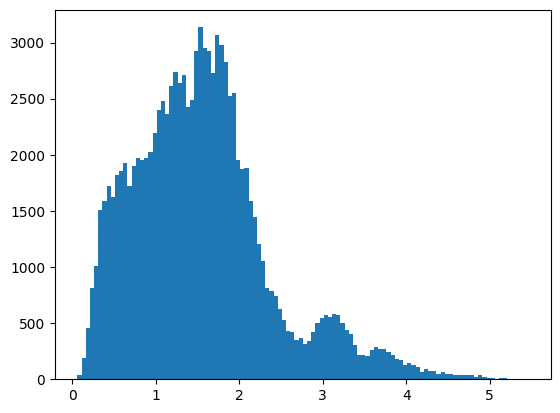

In [8]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("dr7_quasar.npy")

z = data['redshift']
print(len(z))
plt.hist(z, bins=int(np.sqrt(len(z))/3))

iniziamo con il rejection sampling. l'obiettivo è ricreare nummericamente la pdf, imitando quella che ho, per generare più punti.

Efficienza accept/reject: 0.288


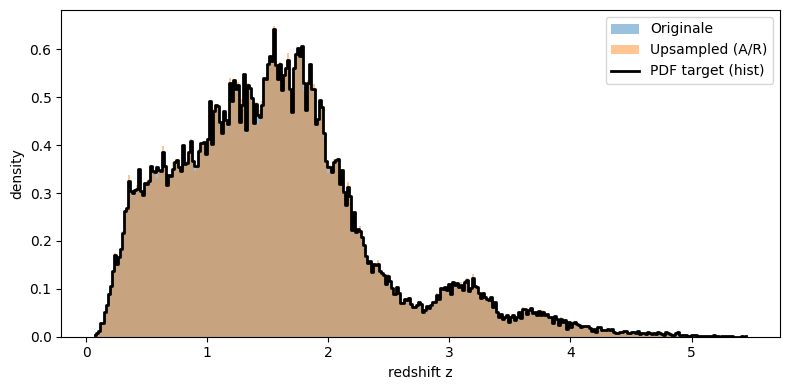

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) Carica i dati
# =========================
data = np.load("dr7_quasar.npy")
z = data["redshift"]

# =========================
# 2) Stima PDF con istogramma (senza interpolazione)
# =========================
bins = int(np.sqrt(len(z)))  # niente np.int (deprecato)
hist, edges = np.histogram(z, bins=bins, density=True)

xmin, xmax = edges[0], edges[-1]
fmax = hist.max()

def pdf_hist(x, hist, edges):
    """
    PDF a tratti costante definita dai bin dell'istogramma.
    Restituisce 0 fuori dall'intervallo.
    """
    x = np.asarray(x)
    out = np.zeros_like(x, dtype=float)

    # indice del bin: per ogni x trova in quale intervallo edges sta
    idx = np.searchsorted(edges, x, side="right") - 1

    # validi: bin interni [0, len(hist)-1]
    m = (idx >= 0) & (idx < len(hist))
    out[m] = hist[idx[m]]

    return out

# =========================
# 3) Accept-Reject (proposal uniforme)
# =========================
def sample_accept_reject_hist(hist, edges, n_samples, rng=None):
    rng = np.random.default_rng(rng)

    xmin, xmax = edges[0], edges[-1]
    fmax = hist.max()

    accepted = []
    n_acc = 0
    n_try = 0

    while n_acc < n_samples:
        # batch per velocizzare
        m = max(1000, 2 * (n_samples - n_acc))
        x = rng.uniform(xmin, xmax, size=m)
        y = rng.uniform(0.0, fmax, size=m)

        fx = pdf_hist(x, hist, edges)
        keep = y <= fx

        x_ok = x[keep]
        accepted.append(x_ok)

        n_acc += x_ok.size
        n_try += m

    samples = np.concatenate(accepted)[:n_samples]
    eff = n_samples / n_try
    return samples, eff

# Upsampling: ad esempio 5x i dati originali
z_up, efficiency = sample_accept_reject_hist(hist, edges, n_samples=5 * len(z), rng=42)
print(f"Efficienza accept/reject: {efficiency:.3f}")

# =========================
# 4) Controllo visivo
# =========================
plt.figure(figsize=(8, 4))
plt.hist(z, bins=edges, density=True, alpha=0.45, label="Originale")
plt.hist(z_up, bins=edges, density=True, alpha=0.45, label="Upsampled (A/R)")

# disegna la PDF a gradini (istogramma target)
centers = 0.5 * (edges[:-1] + edges[1:])
plt.step(centers, hist, where="mid", color="k", lw=2, label="PDF target (hist)")

plt.xlabel("redshift z")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

rivedo un tot e lo faccio, boh

provo con sto metodo, provo con un'interpolazione di veri tipi, provo con cose varie e vediamo. faccio anche dei test. provo anche altro metodo